In [1]:
import os
import sys
import scipy
import numpy as np
import networkx as nx
import skimage as ski
from skimage.io import imread
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist

current_dir = os.path.dirname(os.path.abspath(os.getcwd()))
project_root = os.path.abspath(os.path.join(current_dir, '.'))
sys.path.append(project_root)

from src.system.dataset_manager import Dataset_Manager
from src.system.preprocessing import Preprocessing
from src.system.features import FeatureExtractor
import src.system.graph_analysis as graph

dataset = Dataset_Manager()
preprocessing = Preprocessing()
feature_extractor = FeatureExtractor()

/Users/skowronek/Documents/WormAnalysis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Put the path of the image you want to analyse :

In [2]:
#img_path = "/Users/skowronek/Documents/WormAnalysis/data/Mutant/MutEN6024-50.tif"

#img_path = "/Users/skowronek/Documents/WormAnalysis/data/mut50.tif"
#img_path = "/Users/skowronek/Documents/WormAnalysis/data/wt50.tif"
#img_path = "/Users/skowronek/Documents/WormAnalysis/data/mut100-1.tif"
#img_path = "/Users/skowronek/Documents/WormAnalysis/data/mut100-2.tif"


img_path = "/Users/skowronek/Documents/WormAnalysis/data/img_sephora/WT/wt_100.tif"

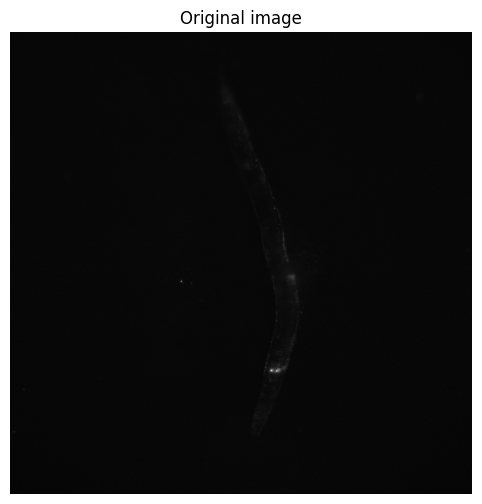

In [3]:
img = imread(img_path)
img = dataset._preprocess_image(img) # change size and type

plt.figure(figsize=(8, 6))
plt.imshow(img, cmap='gray')  
plt.title('Original image')
plt.axis('off')  
plt.show()

    [Preprocessing] Starting worm segmentation
    [Preprocessing] YOLO predict: 1.3852s
    [Preprocessing] Segmentation (mask): 0.0002s
    [Preprocessing] Segmentation (keep largest component): 0.0071s
    [Preprocessing] Total segmentation (YOLO): 1.4660s


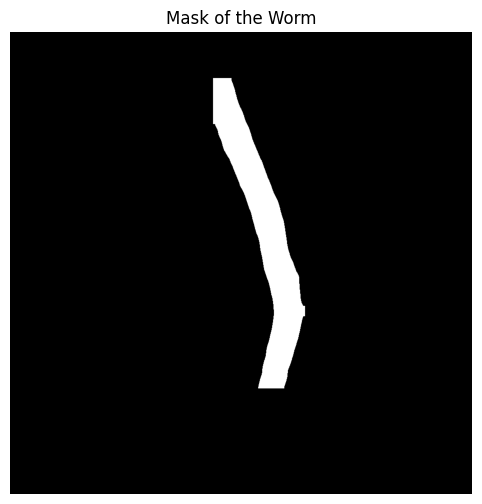

In [4]:
worm_mask = preprocessing.worm_segmentation(img) # Get worm mask
plt.figure(figsize=(8, 6))
plt.imshow(worm_mask, cmap='gray')  
plt.title('Mask of the Worm')
plt.axis('off')  
plt.show()

In [5]:
preprocessing.is_coiled_worm(worm_mask) # Detect the coiled worm

False

/!\ We can't continue if it's a coiled worm

# I - Get the puncta position

## Get a first approximation of the puncta position using filters

### 1. Apply Frangi filter

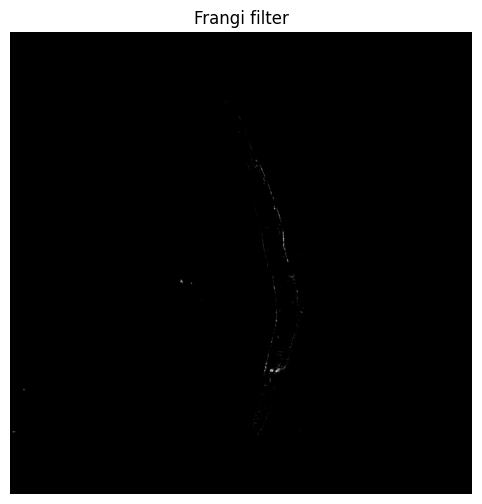

In [19]:
# valeurs par défaut : 0.5 ; 0.5 ; 70
# changer le beta en 0.8 a l'air pas mal
frangi_response = ski.filters.frangi(
    img,
    black_ridges=False,
    sigmas=range(1, 3, 1),
    alpha=0.8,
    beta=0.5,
    gamma=10
)

plt.figure(figsize=(8, 6))
plt.imshow(frangi_response, cmap='gray')  
plt.title('Frangi filter')
plt.axis('off')  
plt.show()

### 2. Apply hysteresis

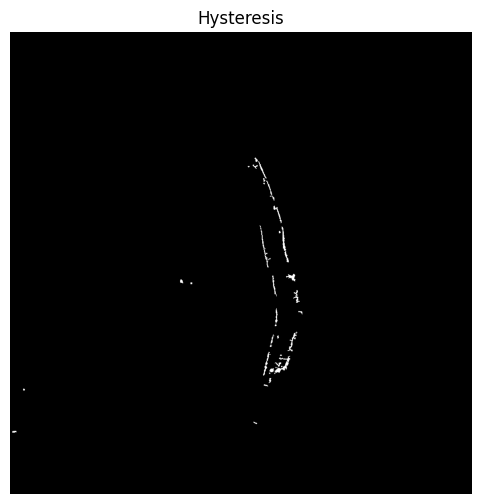

In [20]:
hysteresis_response = ski.filters.apply_hysteresis_threshold(frangi_response, 0.01, 0.2)

plt.figure(figsize=(8, 6))
plt.imshow(hysteresis_response, cmap='gray')  
plt.title('Hysteresis')
plt.axis('off')  
plt.show()

### 3. Clean up response from small objects

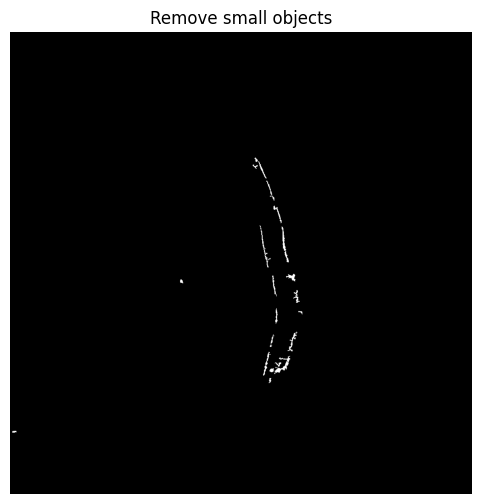

In [21]:
clean_response = preprocessing.remove_small_objects(hysteresis_response)

plt.figure(figsize=(8, 6))
plt.imshow(clean_response, cmap='gray')  
plt.title('Remove small objects')
plt.axis('off')  
plt.show()

### 4. Keep line-like components

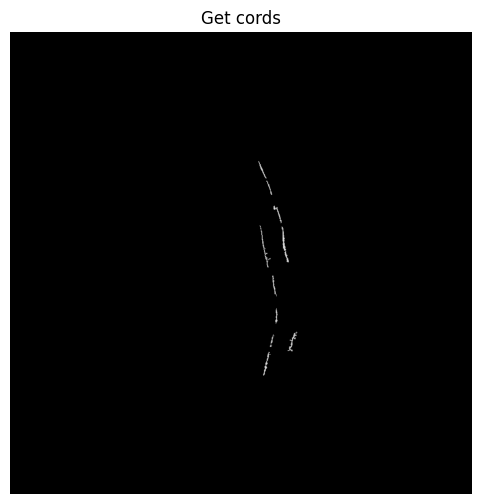

In [22]:
labeled_image = ski.measure.label(clean_response)
components = ski.measure.regionprops(labeled_image)
label_components = np.zeros_like(labeled_image)
for component in components:
    if component.major_axis_length / component.minor_axis_length > 4:
        label_components[labeled_image == component.label] = 1 
response = label_components
response = (response - response.min()) / (response.max() - response.min()) # normalize

# Create mask
threshold = np.percentile(response, 95)
mask = response > threshold

# Apply mask
masked_img = img.copy()
masked_img[~mask] = 0

plt.figure(figsize=(8, 6))
plt.imshow(masked_img, cmap='gray')  
plt.title('Get cords')
plt.axis('off')  
plt.show()

### 5. Find local maxima

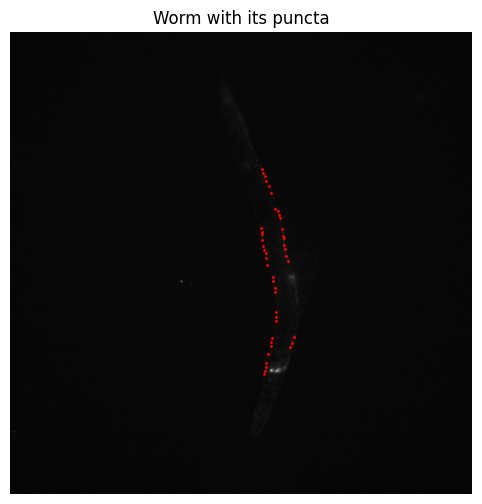

In [23]:
local_max = ski.feature.peak_local_max(
    masked_img,
    min_distance=5,
    threshold_abs=0,
    exclude_border=False
)

plt.figure(figsize=(8, 6))
plt.imshow(img, cmap='gray')  
plt.title('Worm with its puncta')
plt.scatter(local_max[:, 1], local_max[:, 0], c='red', s=1, marker='o', label='Local Maxima')
plt.axis('off')  
plt.show()

## Improving the puncta position estimation using graph analysis

### 1. Skeletonize worm and get main branch

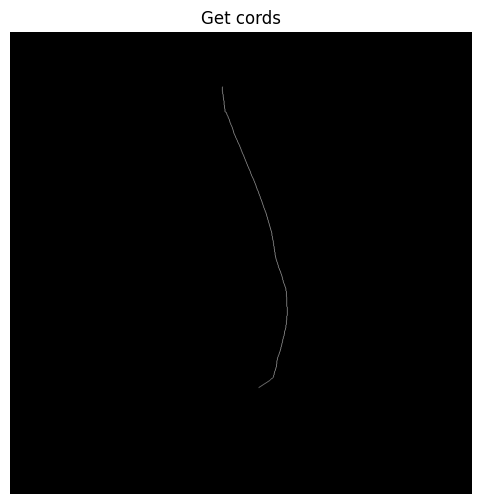

In [24]:
skeleton = ski.morphology.skeletonize(worm_mask)
G = graph._skeleton_to_graph(skeleton)  # Create initial graph from skeleton
G, skeleton = graph._skeleton_keep_main_branch(G, skeleton, local_max, keep=1)

plt.figure(figsize=(8, 6))
plt.imshow(skeleton, cmap='gray')  
plt.title('Get cords')
plt.axis('off')  
plt.show()

### 2. Decompose skeleton into segments

In [25]:
n_segments = 20
skel_path = graph._order_skeleton_points_skan(skeleton)

n = len(skel_path)
seg_len = max(1, n // n_segments)  # Ensure non-zero segment length
centers = [skel_path[i * seg_len + seg_len // 2] for i in range(min(n_segments, n))]

### 3. Calculate segment statistics

In [26]:
distances = cdist(local_max, centers)
labels = np.argmin(distances, axis=1)
counts = np.bincount(labels, minlength=len(centers))

mean_count = np.mean(counts)
diff_points = counts - mean_count
measure_diff_points = np.sqrt(np.sum(diff_points**2))

### 4. Calculate segment directions

In [27]:
directions = []
for i in range(min(n_segments, n)):
    start_idx = i * seg_len
    end_idx = min((i + 1) * seg_len - 1, n - 1)
            
    if start_idx >= n or end_idx >= n: continue
                
    start = np.array(skel_path[start_idx])
    end = np.array(skel_path[end_idx])
    vec = end - start
    norm = np.linalg.norm(vec)
    vec = vec / norm if norm > 0 else np.zeros_like(start, dtype=float)
    directions.append(vec)

### 5. Decompose segments into slices

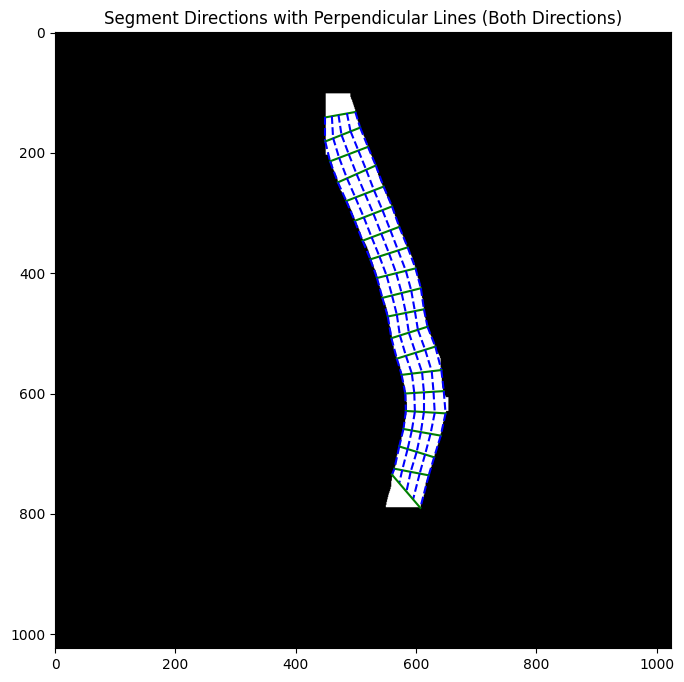

In [28]:
# Set entire border to black
worm_mask[0, :] = worm_mask[-1, :] = worm_mask[:, 0] = worm_mask[:, -1] = 0
dic_segments, median_width = graph._decompose_worm_segments_into_slice(skel_path, worm_mask, n_segments)
    
# Assign each maxima to the slice it belongs to
labels_slice = np.zeros(len(local_max), dtype=int)
def get_slice_label(dist, threshold1, threshold2):
    """Determine slice label based on distance and thresholds."""
    if dist < threshold1 and dist < threshold2:
        return 0  # Both thresholds exceeded (closest)
    elif dist > threshold1 and dist < threshold2:
        return 1  # Middle range
    else:  # dist > threshold1 and dist > threshold2
        return 2  # Furthest range

for i, point in enumerate(local_max):
    seg_idx = labels[i]
    segment = skel_path[seg_idx * seg_len: (seg_idx + 1) * seg_len]
    
    dist_to_seg, sign = graph._signed_distance_to_segment_2d(segment, point)
    
    if sign > 0:
        # Positive direction: use indices 5 and 7
        slice_offset = get_slice_label(dist_to_seg, dic_segments[seg_idx][5], dic_segments[seg_idx][7])
        labels_slice[i] = 2 - slice_offset  # Maps 0,1,2 to 2,1,0
    else:
        # Negative direction: use indices 6 and 8  
        slice_offset = get_slice_label(dist_to_seg, dic_segments[seg_idx][6], dic_segments[seg_idx][8])
        labels_slice[i] = 3 + slice_offset  # Maps 0,1,2 to 3,4,5     

plt.figure(figsize=(8, 8))
plt.imshow(worm_mask, cmap='gray')
for i in range(n_segments-1):
    plt.plot([dic_segments[i][4][1], dic_segments[i][3][1]], [dic_segments[i][4][0], dic_segments[i][3][0]], 'g-', label=f'Segment {i}' if i == 0 else "")
    start = dic_segments[i][0]
    end = dic_segments[i+1][0]
    plt.plot([start[1], end[1]], [start[0], end[0]], 'b--', label=f'Segment {i}' if i == 0 else "")
    start = dic_segments[i][1]
    end = dic_segments[i+1][1]
    plt.plot([start[1], end[1]], [start[0], end[0]], 'b--', label=f'Segment {i}' if i == 0 else "")
    start = dic_segments[i][2]
    end = dic_segments[i+1][2]
    plt.plot([start[1], end[1]], [start[0], end[0]], 'b--', label=f'Segment {i}' if i == 0 else "")
    start = dic_segments[i][3]
    end = dic_segments[i+1][3]
    plt.plot([start[1], end[1]], [start[0], end[0]], 'b--', label=f'Segment {i}' if i == 0 else "")
    start = dic_segments[i][4]
    end = dic_segments[i+1][4]
    plt.plot([start[1], end[1]], [start[0], end[0]], 'b--', label=f'Segment {i}' if i == 0 else "")
plt.plot([dic_segments[n_segments-1][4][1], dic_segments[n_segments-1][3][1]], [dic_segments[n_segments-1][4][0], dic_segments[n_segments-1][3][0]], 'g-', label=f'Segment {n_segments-1}' if n_segments-1 == 0 else "")
plt.title("Segment Directions with Perpendicular Lines (Both Directions)")
plt.show()

### 6. Calculate segment statistics

In [29]:
Nb_slice = np.zeros(6, dtype=int)
Diff_slice = np.zeros(6, dtype=int)
for i in range(6):
    Nb_slice[i] = np.sum(labels_slice == i)
    Diff_slice[i] = Nb_slice[i] - np.mean(Nb_slice)
measure_diff_slice = np.sqrt(np.sum(Diff_slice**2))

### 7. Create graph from maxima coordinates and segment directions

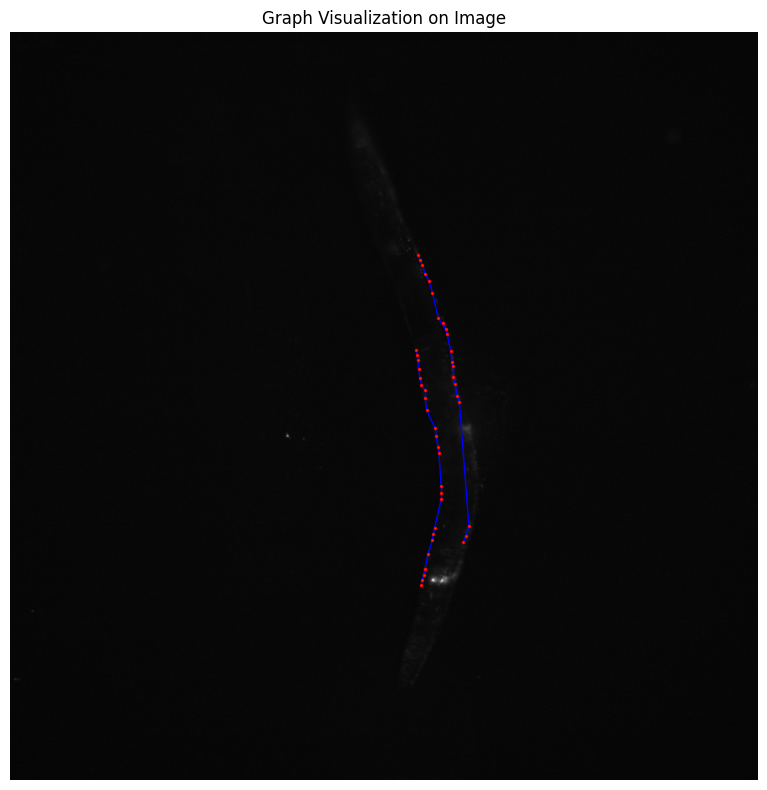

In [30]:
G = nx.Graph()
for i, p1 in enumerate(local_max):
    node1 = tuple(p1)
    G.add_node(node1, centroid=p1)
    seg_idx1 = min(labels[i], len(directions) - 1)
    dir_vec = directions[seg_idx1]
    slices1 = labels_slice[i]

    best_j = None
    min_dist = np.inf

    for j, p2 in enumerate(local_max):
        if i == j: continue
                
        if abs(slices1 - labels_slice[j]) > 1: continue
                
        vec = p2 - p1
        dist = np.linalg.norm(vec)
                
        if dist == 0: continue
                
        vec_normed = vec / dist
        dot = np.dot(vec_normed, dir_vec)
        
        if dot > 0.9 and dist < min_dist:
            best_j = j
            min_dist = dist

    if best_j is not None:
        node2 = tuple(local_max[best_j])
        G.add_node(node2, centroid=local_max[best_j])
        G.add_edge(node1, node2)
        
       
       
        
        
plt.figure(figsize=(8, 8))
plt.imshow(img, cmap='gray', alpha=1)
# Extract node positions
pos = {}
for node in G.nodes():
    # NetworkX uses (x, y) but image coordinates are (row, col) = (y, x)
    # So we need to flip coordinates for proper display
    pos[node] = (node[1], node[0])  # (col, row) for matplotlib

# Draw edges
nx.draw_networkx_edges(G, pos, 
                        edge_color='blue', 
                        width=1, 
                        alpha=1)

# Draw nodes
nx.draw_networkx_nodes(G, pos, 
                        node_color='yellow', 
                        node_size=2, 
                        alpha=1,
                        edgecolors='red',
                        linewidths=1)

# Optionally add node labels (coordinates)
# nx.draw_networkx_labels(G, pos, font_size=8, font_color='white')

plt.title('Graph Visualization on Image')
plt.axis('off')  # Remove axes
plt.tight_layout()
plt.show()

### 8. Final processing of graph and skeleton - keep only the main branch

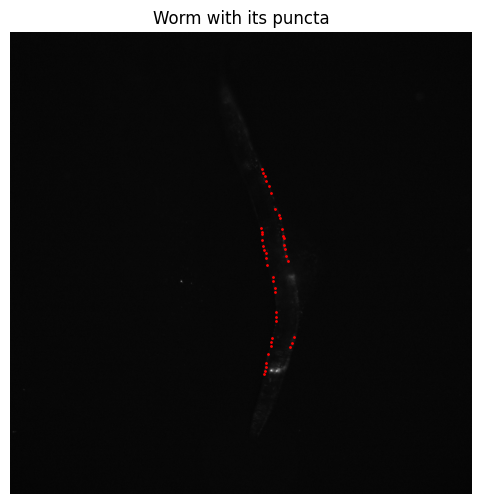

In [31]:
if np.sum(np.isin(labels_slice, [0, 1])) > len(local_max) / 5 and np.sum(np.isin(labels_slice, [4, 5])) > len(local_max) / 5:
    NUMBER_OF_CORDS = 2
else:
    NUMBER_OF_CORDS = 1
skeleton = graph._graph_to_skeleton(G, shape=worm_mask.shape)
    
G, skeleton = graph._skeleton_keep_main_branch(G, skeleton, local_max, keep=NUMBER_OF_CORDS)

# Get final maxima
maxima = np.array([node for node in local_max if 0 <= node[0] < skeleton.shape[0] 
                    and 0 <= node[1] < skeleton.shape[1] and skeleton[node[0], node[1]] == 1])    


plt.figure(figsize=(8, 6))
plt.imshow(img, cmap='gray')  
plt.title('Worm with its puncta')
plt.scatter(maxima[:, 1], maxima[:, 0], c='red', s=1, marker='o', label='Local Maxima')
plt.axis('off')  
plt.show()              

# II - Reconstruct the puncta

## Construct a mask using the puncta position

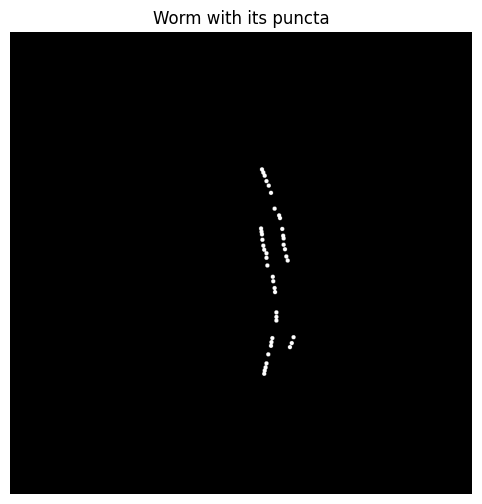

In [32]:
mask_synapse = np.zeros_like(img)
height, width = img.shape

for coord in maxima:
    rr, cc = ski.draw.disk(coord, 5)
    # Filter coordinates within image boundaries
    valid_coords = (rr >= 0) & (rr < height) & (cc >= 0) & (cc < width)
    rr = rr[valid_coords]
    cc = cc[valid_coords]
    # Update mask with valid coordinates
    mask_synapse[rr, cc] = 1
    
plt.figure(figsize=(8, 6))
plt.imshow(mask_synapse, cmap='gray')  
plt.title('Worm with its puncta')
plt.axis('off')  
plt.show()  

## Refining the mask

### 1. Apply the watershed algorithm to separate regions

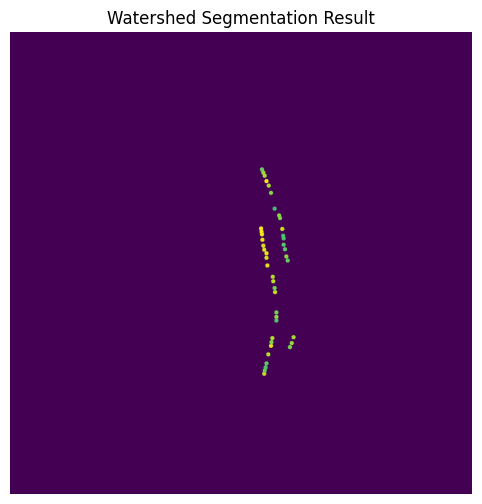

In [33]:
rough_segmented = feature_extractor._watershed_segmentation(maxima, img, mask_synapse)

plt.figure(figsize=(8, 6))
plt.imshow(rough_segmented, cmap='viridis')
plt.title('Watershed Segmentation Result')
plt.axis('off') 
plt.show()

### 2. For each region, we will search for new puncta

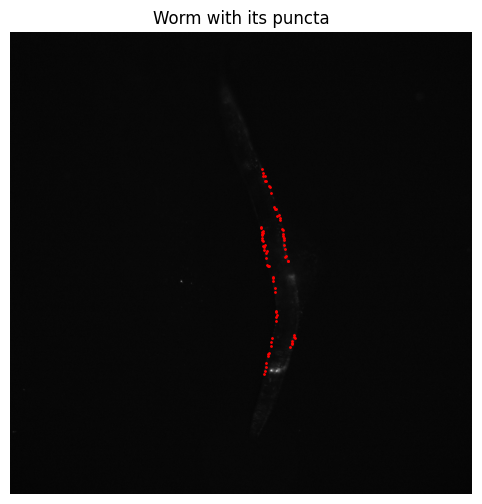

In [34]:
# Smooth the image to reduce noise before refinement.
image_smooth = ski.filters.gaussian(img, sigma=0.5)

# Find and add additional synapse candidates.
additional_synapses = []

for region in ski.measure.regionprops(rough_segmented, intensity_image=image_smooth):
    new_centers = feature_extractor._find_additional_synapses(region, image_smooth, rough_segmented)
    additional_synapses.extend(new_centers)

coord = np.vstack((maxima, additional_synapses))
coord = {tuple(row) for row in coord}
coord = np.array(list(coord))

plt.figure(figsize=(8, 6))
plt.imshow(img, cmap='gray')  
plt.title('Worm with its puncta')
plt.scatter(coord[:, 1], coord[:, 0], c='red', s=1, marker='o', label='Local Maxima')
plt.axis('off')  
plt.show()

### 3. Now we can really start to refined the puncta regions

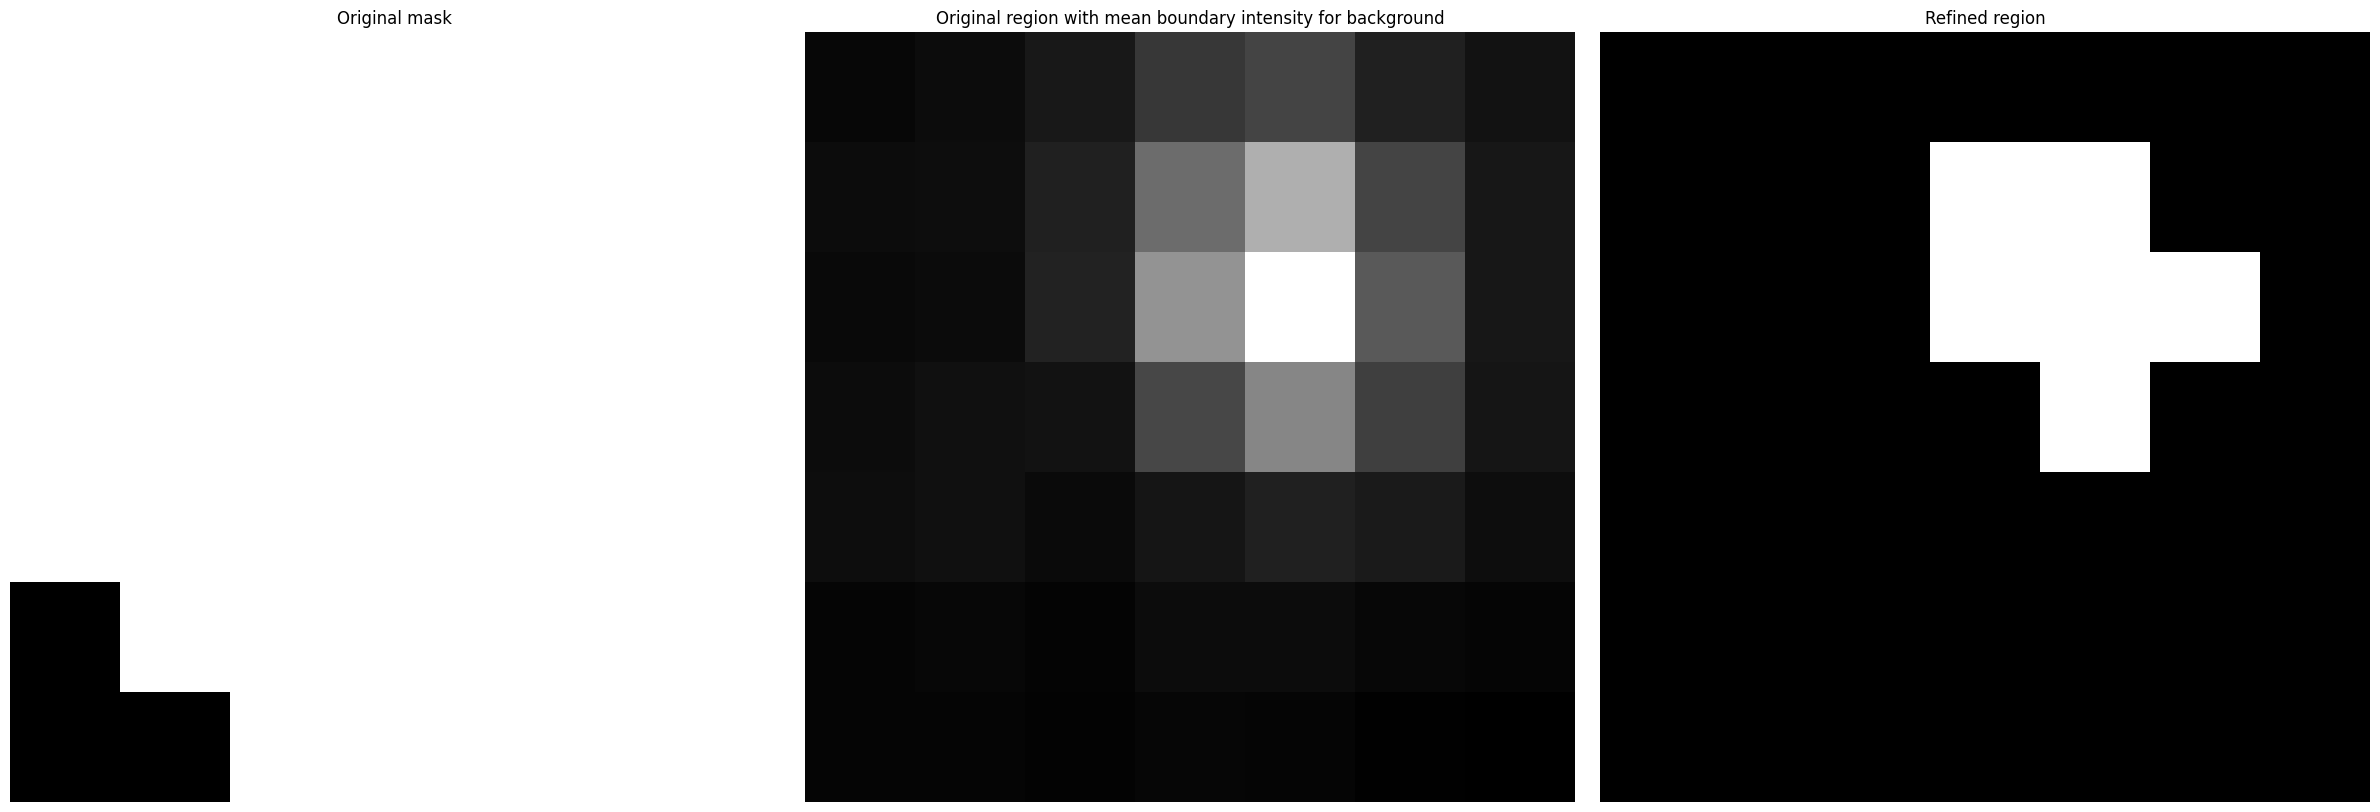

In [35]:
final_segmented = feature_extractor._watershed_segmentation(coord, image_smooth, mask_synapse)
refined_segmented = np.zeros_like(final_segmented)

show_exemple = True
# Refine each region using K-means clustering.
for region in ski.measure.regionprops(final_segmented, intensity_image=image_smooth):
    minr, minc, maxr, maxc = region.bbox
    mask = (final_segmented[minr:maxr, minc:maxc] == region.label)
    
    # Compute mean boundary intensity
    boundary = ski.morphology.dilation(mask, ski.morphology.disk(1)) ^ mask  # Find boundary pixels
    if not image_smooth[minr:maxr, minc:maxc][boundary].size:
        mean_boundary = 0
    else:
        mean_boundary = np.mean(image_smooth[minr:maxr, minc:maxc][boundary])
    
    
    # Construct new window
    new_window = image_smooth[minr:maxr, minc:maxc].copy()
    new_window[~mask] = mean_boundary  # Replace background with mean boundary intensity

    # Apply K-means to the intensity and binary mask.
    I = new_window / new_window.max()  # Normalize intensities
    B = mask.astype(float) * 0  # Binary weight
    features = np.column_stack((I.flatten(), B.flatten()))  # 2D feature space
    
    if features.shape[0] < 2: # Not enough features for region
        labels = np.zeros_like(features)
        continue
    
    kmeans = KMeans(n_clusters=2, random_state=0, n_init=10)
    labels = kmeans.fit_predict(features)

    # Determine foreground and update segmentation
    refined_region = labels.reshape(mask.shape)
    foreground_label = np.argmax([np.mean(I[refined_region == 0]), np.mean(I[refined_region == 1])])
    foreground_mask = (refined_region == foreground_label)
    
    # Keep only the largest connected component in the foreground        
    labeled_fg = ski.measure.label(foreground_mask, connectivity=1)
    regions = ski.measure.regionprops(labeled_fg)
    if regions:
        largest_region = max(regions, key=lambda r: r.area)
        largest_component_mask = (labeled_fg == largest_region.label)
        filled_component_mask = scipy.ndimage.binary_fill_holes(largest_component_mask, structure=np.array([[0,1,0],
                                                                                                            [1,1,1],
                                                                                                            [0,1,0]])) 
    else:
        filled_component_mask = np.zeros_like(foreground_mask)
    
    # Update refined mask
    refined_mask = np.zeros_like(mask, dtype=np.int32)
    refined_mask[filled_component_mask] = region.label
    refined_segmented[minr:maxr, minc:maxc][refined_mask > 0] = region.label
    
    if show_exemple:
        # Create a figure with a specified size for the combined image
        fig, axes = plt.subplots(1, 3, figsize=(24, 8)) # 1 row, 3 columns
        # Visualize region (first subplot)
        axes[0].imshow(mask, cmap='gray')
        axes[0].set_title(f"Original mask")
        axes[0].axis('off') # Turn off axis labels and ticks
        # Visualize new window (second subplot)
        axes[1].imshow(new_window, cmap='gray')
        axes[1].set_title(f"Original region with mean boundary intensity for background")
        axes[1].axis('off')
        # Visualize refined region (third subplot)
        axes[2].imshow(refined_mask, cmap='gray')
        axes[2].set_title(f"Refined region")
        axes[2].axis('off')
        # Adjust layout to prevent overlapping titles
        plt.tight_layout()
        # Show the combined image
        plt.show()
        show_exemple = False

# Calculate region properties for the refined segmented image
region_props = ski.measure.regionprops(refined_segmented, intensity_image=img)

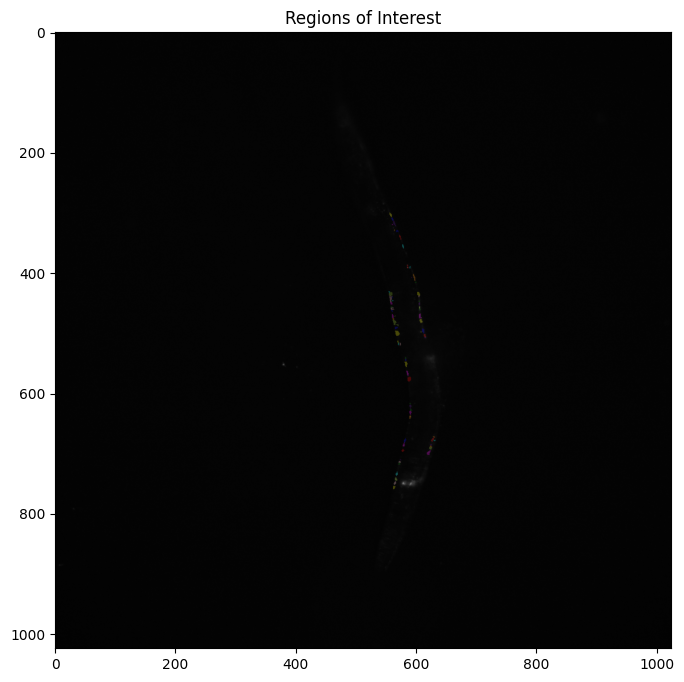

In [36]:
labeled_image = ski.color.label2rgb(refined_segmented, image=img, bg_label=0, alpha=0.5)
            
# colorize the original_image with above regions of interest
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img, cmap='gray')  
ax.imshow(labeled_image, alpha=0.5)
ax.set_title('Regions of Interest')
plt.show()